# NORMAL LLM BASED LANGGRAPH WORKFLOW

In [ ]:
from langgraph.graph import StateGraph,START,END
from langchain_huggingface import ChatHuggingFace,HuggingFaceEndpoint
from dotenv import load_dotenv
from typing import TypedDict
load_dotenv()

True

In [ ]:
llm=HuggingFaceEndpoint(
    repo_id="openai/gpt-oss-120b",
    task="text-generation"
)

model=ChatHuggingFace(llm=llm)

In [ ]:
class LLMState(TypedDict):
    question:str
    answer:str

In [ ]:
# def llm_qa(state:LLMState)->LLMState:
#     question=state['question']
#     prompt=f'Answer the following question: {question}'

#     answer=model.invoke(prompt)

#     return {
#         "question": question,
#         "answer": answer.content
# }


def llm_qa(state: LLMState) -> LLMState:

    # extract the question from state
    question = state['question']

    # form a prompt
    prompt = f'Answer the following question {question}'

    # ask that question to the LLM
    answer = model.invoke(prompt).content

    # update the answer in the state
    state['answer'] = answer

    return state

In [ ]:
graph=StateGraph(LLMState)

graph.add_node('System',llm_qa)
graph.add_edge(START,'System')
graph.add_edge('System',END)

In [ ]:
workflow=graph.compile()

In [ ]:
initial_state={'question':'how far is the moon from earth?'}
final_state=workflow.invoke(initial_state)

In [ ]:
print("\nFinal State:")
print(final_state)


Final State:
{'question': 'how far is the moon from earth?', 'answer': 'The Moon orbits Earth at an average distance of **about\u202f384,400\u202fkilometers (≈238,900\u202fmiles)**.  \n\n- **Closest approach (perigee):** ~363,300\u202fkm (≈225,600\u202fmi)  \n- **Farthest point (apogee):** ~405,500\u202fkm (≈252,000\u202fmi)  \n\nThese values vary because the Moon’s orbit is slightly elliptical, but the 384,400\u202fkm figure is the commonly quoted average distance.'}


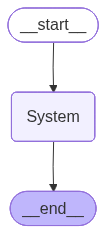

In [ ]:
graph.compile()

In [ ]:
model.invoke('How far is the moon from earth?').content

'The Moon orbits Earth at an average distance of **about\u202f384\u202f400\u202fkilometers** (≈\u202f238\u202f900\u202fmiles).  \n\nBecause the Moon’s orbit is elliptical, the actual distance varies:\n\n| Position | Approximate distance from Earth |\n|----------|---------------------------------|\n| **Perigee** (closest) | 363\u202f300\u202fkm\u202f≈\u202f225\u202f600\u202fmi |\n| **Apogee** (farthest) | 405\u202f500\u202fkm\u202f≈\u202f252\u202f000\u202fmi |\n| **Average (semi‑major axis)** | 384\u202f400\u202fkm\u202f≈\u202f238\u202f900\u202fmi |\n\nSo, on any given night the Moon will be somewhere between ~363,000\u202fkm and ~405,000\u202fkm away, with the mean distance hovering around 384,400\u202fkm.'